# Part A: EDA
This notebook handles data loading, profiling, cleaning, and multivariate EDA.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import logging
import os
import warnings
warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
os.makedirs('charts', exist_ok=True)
os.makedirs('outputs', exist_ok=True)


## 1. Data Load
Load the Titanic dataset ONLY ONCE using sns.load_dataset and save to `titanic.csv`.

In [2]:
logging.info('Loading Titanic dataset')
df = sns.load_dataset('titanic')
df.to_csv('titanic.csv', index=False)
logging.info('Saved raw data to titanic.csv')
display(df.head())


INFO: Loading Titanic dataset


INFO: Saved raw data to titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Basic Profiling
Examine the dataset info, description, and shape.

In [3]:
print('--- INFO ---')
df.info()
print('\n--- DESCRIBE ---')
display(df.describe(include='all'))
print('\n--- SHAPE ---')
print(df.shape)


--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

--- DESCRIBE ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- SHAPE ---
(891, 15)


## 3. Missing Value Analysis & Strategy
We calculate the percentage of missing values for all affected columns and apply the assignment rules:
- Missing < 5%: Drop rows (e.g. `embarked`, `embark_town`)
- Missing 5%-30%: Impute (e.g. `age` -> Median Imputation during EDA)
- Missing > 30%: Encode as missing or drop (e.g. `deck` -> Encoded as 'Missing' because deck location correlates with survival rate due to proximity to lifeboats).

We perform median imputation to 'age' here for EDA purposes. Formal imputation for ML models will be handled via Scikit-Learn Pipelines to prevent data leakage.

In [4]:
missing_pct = df.isnull().mean() * 100
missing_cols = missing_pct[missing_pct > 0].sort_values(ascending=False)
print('Missing Value Percentages:')
print(missing_cols)

# Apply Rules
logging.info('Handling missing values according to strict rules.')

# Rule > 30%: Encode 'deck' as 'Missing'
df['deck'] = df['deck'].cat.add_categories('Missing').fillna('Missing')

# Rule 5%-30%: 'age' - Median imputation
median_age = df['age'].median()
df['age'].fillna(median_age, inplace=True)
logging.info(f'Imputed age with median: {median_age}')

# Rule < 5%: Drop rows for 'embarked' and 'embark_town'
df.dropna(subset=['embarked', 'embark_town'], inplace=True)

print('\nRemaining missing values:')
print(df.isnull().sum())


INFO: Handling missing values according to strict rules.


INFO: Imputed age with median: 28.0


Missing Value Percentages:
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64

Remaining missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck             0
embark_town      0
alive            0
alone            0
dtype: int64


## 4. Univariate Analysis: Age and Fare
Histograms and Box Plots for Age and Fare.

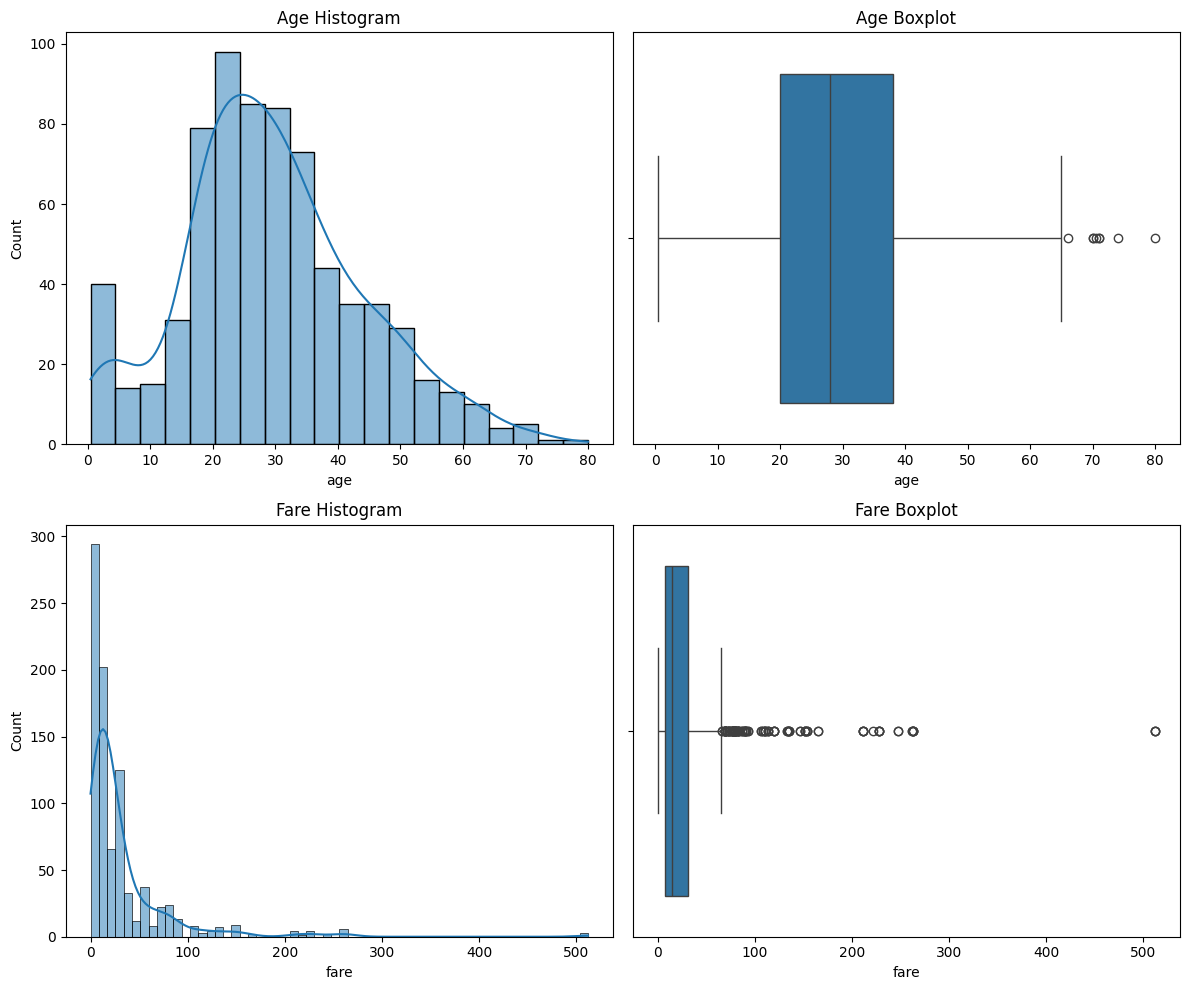

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df['age'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Age Histogram')
sns.boxplot(x=df['age'], ax=axes[0, 1])
axes[0, 1].set_title('Age Boxplot')

sns.histplot(df['fare'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Fare Histogram')
sns.boxplot(x=df['fare'], ax=axes[1, 1])
axes[1, 1].set_title('Fare Boxplot')

plt.tight_layout()
plt.savefig('charts/univariate_age_fare.png')
plt.show()


**Interpretation:** The Age distribution is roughly normal but with a high concentration at the median due to imputation. Fare is highly right-skewed with massive upper-bound outliers.

## 5. IQR Outlier Detection
Detect outliers for Age and Fare using the IQR rule.

In [6]:
def detect_outliers(col_name):
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = df[(df[col_name] < lower_bound) | (df[col_name] > upper_bound)].shape[0]
    
    print(f'--- {col_name.capitalize()} ---')
    print(f'Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}')
    print(f'Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}')
    print(f'Outlier Count: {outlier_count}\n')

detect_outliers('age')
detect_outliers('fare')


--- Age ---
Q1: 20.00, Q3: 38.00, IQR: 18.00
Lower Bound: -7.00, Upper Bound: 65.00
Outlier Count: 8

--- Fare ---
Q1: 7.90, Q3: 31.00, IQR: 23.10
Lower Bound: -26.76, Upper Bound: 65.66
Outlier Count: 114



## 6. Central Tendency for Fare
Compute Mean, Median, Mode to infer skewness.

In [7]:
fare_mean = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode = df['fare'].mode()[0]

print(f'Fare Mean: {fare_mean:.2f}')
print(f'Fare Median: {fare_median:.2f}')
print(f'Fare Mode: {fare_mode:.2f}')

if fare_mean > fare_median:
    skewness = 'Right Skewed'
elif fare_mean < fare_median:
    skewness = 'Left Skewed'
else:
    skewness = 'Symmetric'

print(f'Distribution is {skewness}')


Fare Mean: 32.10
Fare Median: 14.45
Fare Mode: 8.05
Distribution is Right Skewed


## 7. Survival Rates via Boolean Masking
Compute exact survival percentages based on masking conditions.

In [8]:
# (a) by Sex
male_mask = df['sex'] == 'male'
female_mask = df['sex'] == 'female'
print(f"Survival Rate (Male): {df[male_mask]['survived'].mean()*100:.2f}%")
print(f"Survival Rate (Female): {df[female_mask]['survived'].mean()*100:.2f}%")

# (b) by Pclass
for c in sorted(df['pclass'].unique()):
    mask = df['pclass'] == c
    print(f"Survival Rate (Pclass {c}): {df[mask]['survived'].mean()*100:.2f}%")

# (c) by Sex AND Pclass
for sex in ['male', 'female']:
    for c in sorted(df['pclass'].unique()):
        mask = (df['sex'] == sex) & (df['pclass'] == c)
        print(f"Survival Rate ({sex.capitalize()}, Pclass {c}): {df[mask]['survived'].mean()*100:.2f}%")


Survival Rate (Male): 18.89%
Survival Rate (Female): 74.04%
Survival Rate (Pclass 1): 62.62%
Survival Rate (Pclass 2): 47.28%
Survival Rate (Pclass 3): 24.24%
Survival Rate (Male, Pclass 1): 36.89%
Survival Rate (Male, Pclass 2): 15.74%
Survival Rate (Male, Pclass 3): 13.54%
Survival Rate (Female, Pclass 1): 96.74%
Survival Rate (Female, Pclass 2): 92.11%
Survival Rate (Female, Pclass 3): 50.00%


## 8. Correlation Matrix
Generate correlation heatmap restricted to specific numerical features.

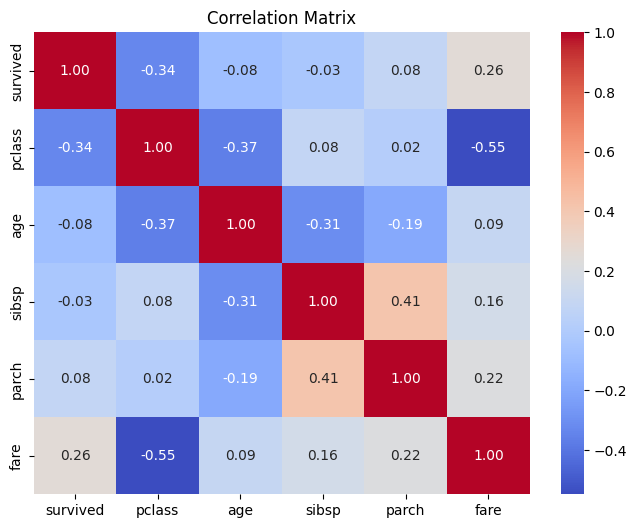

Top 2 correlated feature pairs:
pclass  fare     0.548193
sibsp   parch    0.414542
dtype: float64


In [9]:
cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.savefig('charts/correlation_matrix.png')
plt.show()

# Rank pairs by absolute value
corr_unstack = corr_matrix.abs().unstack()
corr_unstack = corr_unstack[corr_unstack < 1.0].drop_duplicates().sort_values(ascending=False)
print('Top 2 correlated feature pairs:')
print(corr_unstack.head(2))


**Interpretation:** The two strongest correlated feature pairs are `pclass` vs `fare` (negative, higher classes cost more fare), and `pclass` vs `survived` (negative, lower class numbers had a higher survival rate).

## 9. Multivariate Data Story
Visualizing patterns to construct a coherent data story regarding survival.

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


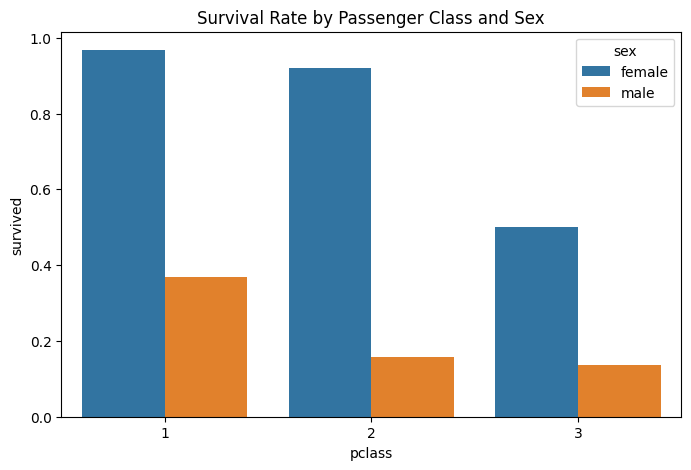

In [10]:
# Chart 1: Survival by Class and Sex
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='pclass', y='survived', hue='sex', errorbar=None)
plt.title('Survival Rate by Passenger Class and Sex')
plt.savefig('charts/story_chart1_bar.png')
plt.show()


**Interpretation (Chart 1):** Females uniformly had higher survival rates than males across all passenger classes. Furthermore, 1st class passengers of both sexes fared significantly better than 3rd class passengers, highlighting socio-economic disparities during the evacuation.

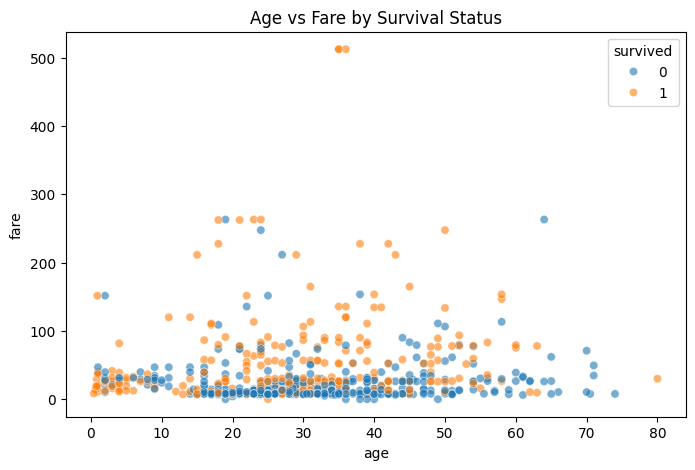

In [11]:
# Chart 2: Age vs Fare by Survival
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='age', y='fare', hue='survived', alpha=0.6)
plt.title('Age vs Fare by Survival Status')
plt.savefig('charts/story_chart2_scatter.png')
plt.show()


**Interpretation (Chart 2):** High fare payers show a much higher density of survival, whereas the dense cluster near zero fare contains mostly non-survivors. Age alone doesn't perfectly separate survivors, but high-fare clusters clearly favor survival.

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


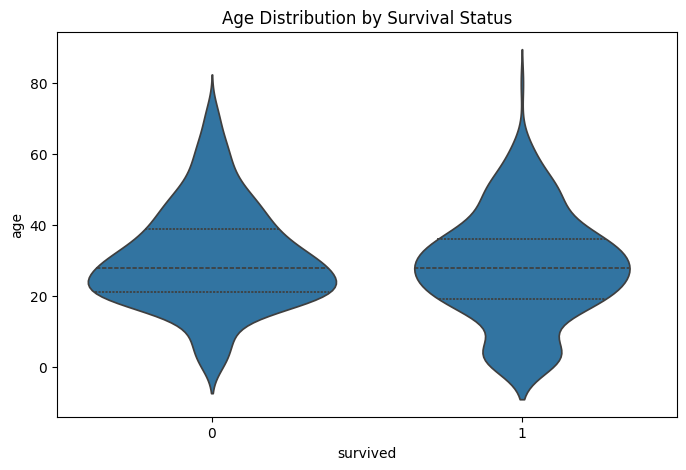

In [12]:
# Chart 3: Age Distribution by Survival
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='survived', y='age', inner='quartile')
plt.title('Age Distribution by Survival Status')
plt.savefig('charts/story_chart3_violin.png')
plt.show()


**Interpretation (Chart 3):** The age distribution for survivors exhibits a noticeable bulge at younger ages, reflecting prioritizing children during evacuation. Non-survivors are heavily concentrated around the young adult/middle-age median.

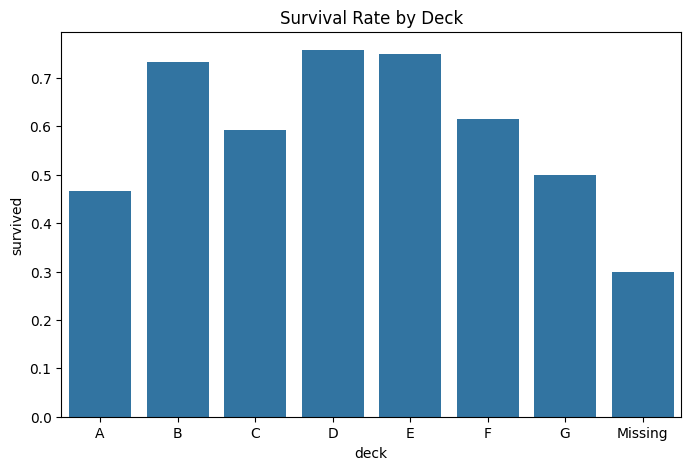

In [13]:
# Chart 4: Survival by Deck
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='deck', y='survived', errorbar=None, order=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Missing'])
plt.title('Survival Rate by Deck')
plt.savefig('charts/story_chart4_deck.png')
plt.show()


**Interpretation (Chart 4):** Passengers on identified upper decks (B, C, D, E) had high survival rates. In stark contrast, passengers whose deck was missing (overwhelmingly 3rd class) had a survival rate near 30%.

## 10. Standardization
Standardize Age and Fare purely for EDA demonstration to show Mean ~ 0 and Std ~ 1.

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

print('--- Before Standardization ---')
print(df[['age', 'fare']].mean())
print(df[['age', 'fare']].std())

scaled_features = scaler.fit_transform(df[['age', 'fare']])
df_scaled = pd.DataFrame(scaled_features, columns=['age_scaled', 'fare_scaled'])

print('\n--- After Standardization ---')
print(df_scaled.mean())
print(df_scaled.std())


--- Before Standardization ---
age     29.642093
fare    32.096681
dtype: float64
age     14.492933
fare    49.697504
dtype: float64

--- After Standardization ---
age_scaled     2.943962e-16
fare_scaled    1.398706e-16
dtype: float64
age_scaled     1.000703
fare_scaled    1.000563
dtype: float64
